Day 2 — Supervised Learning & Preprocessing

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [7]:
from sklearn.datasets import fetch_openml

# Load the Adult Census Income dataset
adult = fetch_openml('adult', version=2, as_frame=True)

# Store the dataset in a DataFrame
df = adult.frame

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (48842, 15)


In [8]:
# Create a binary target variable
df['income'] = (df['class'] == '>50K').astype(int)

# Replace '?' with NaN
df = df.replace('?', np.nan)

print("Missing values:")
print(df.isnull().sum())

Missing values:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
income               0
dtype: int64


In [9]:
# Remove the target columns from the feature set
X = df.drop(['income', 'class'], axis=1)

# Define the target variable
y = df['income']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (48842, 14)
Target shape: (48842,)


In [10]:
# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [11]:
# Preprocessing for numeric features
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

print("Numeric preprocessing pipeline created!")

Numeric preprocessing pipeline created!


In [13]:
# Preprocessing for categorical features
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

print("Categorical preprocessing pipeline created!")

Categorical preprocessing pipeline created!


In [14]:
# Combine numeric and categorical preprocessing
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

print("Complete preprocessing pipeline created!")

Complete preprocessing pipeline created!


In [15]:
# Split the data into training and hold-out test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Hold-out test data:", X_test.shape)

Training data: (39073, 14)
Hold-out test data: (9769, 14)


In [16]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression pipeline
logistic_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

print("Logistic Regression pipeline created!")

Logistic Regression pipeline created!


In [17]:
# Train Logistic Regression using training data only
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained!")

Logistic Regression model trained!


In [18]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree pipeline
tree_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

print("Decision Tree pipeline created!")

Decision Tree pipeline created!


In [19]:
# Train Decision Tree using training data only
tree_model.fit(X_train, y_train)

print("Decision Tree model trained!")

Decision Tree model trained!


In [20]:
# Make predictions on the hold-out test set
logistic_predictions = logistic_model.predict(X_test)
tree_predictions = tree_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Calculate metrics for Logistic Regression
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

# Get prediction probabilities
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

logistic_roc_auc = roc_auc_score(y_test, logistic_probabilities)
logistic_pr_auc = average_precision_score(y_test, logistic_probabilities)

print("Logistic Regression Results")
print("Accuracy:", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall:", round(logistic_recall, 4))
print("F1 Score:", round(logistic_f1, 4))
print("ROC AUC:", round(logistic_roc_auc, 4))
print("PR AUC:", round(logistic_pr_auc, 4))

Logistic Regression Results
Accuracy: 0.8524
Precision: 0.7414
Recall: 0.5885
F1 Score: 0.6562
ROC AUC: 0.9042
PR AUC: 0.7632


In [24]:
# Calculate metrics for Decision Tree
tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_precision = precision_score(y_test, tree_predictions)
tree_recall = recall_score(y_test, tree_predictions)
tree_f1 = f1_score(y_test, tree_predictions)

# Get prediction probabilities
tree_probabilities = tree_model.predict_proba(X_test)[:, 1]

tree_roc_auc = roc_auc_score(y_test, tree_probabilities)
tree_pr_auc = average_precision_score(y_test, tree_probabilities)

print("Decision Tree Results")
print("Accuracy:", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall:", round(tree_recall, 4))
print("F1 Score:", round(tree_f1, 4))
print("ROC AUC:", round(tree_roc_auc, 4))
print("PR AUC:", round(tree_pr_auc, 4))

Decision Tree Results
Accuracy: 0.8141
Precision: 0.6098
Recall: 0.6198
F1 Score: 0.6148
ROC AUC: 0.7475
PR AUC: 0.469


In [25]:
# Create a comparison table for all models

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC', 'PR AUC'],
    
    'Majority Baseline': [
        0.7607, 0.0000, 0.0000, 0.0000, 0.5000, 0.2393
    ],
    
    'Rule-Based Baseline': [
        0.7530, 0.4844, 0.4970, 0.4906, 0.6653, 0.3611
    ],
    
    'Logistic Regression': [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
        logistic_roc_auc,
        logistic_pr_auc
    ],
    
    'Decision Tree': [
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1,
        tree_roc_auc,
        tree_pr_auc
    ]
})

print(comparison.round(4))

      Metric  Majority Baseline  Rule-Based Baseline  Logistic Regression  \
0   Accuracy             0.7607               0.7530               0.8524   
1  Precision             0.0000               0.4844               0.7414   
2     Recall             0.0000               0.4970               0.5885   
3         F1             0.0000               0.4906               0.6562   
4    ROC AUC             0.5000               0.6653               0.9042   
5     PR AUC             0.2393               0.3611               0.7632   

   Decision Tree  
0         0.8141  
1         0.6098  
2         0.6198  
3         0.6148  
4         0.7475  
5         0.4690  


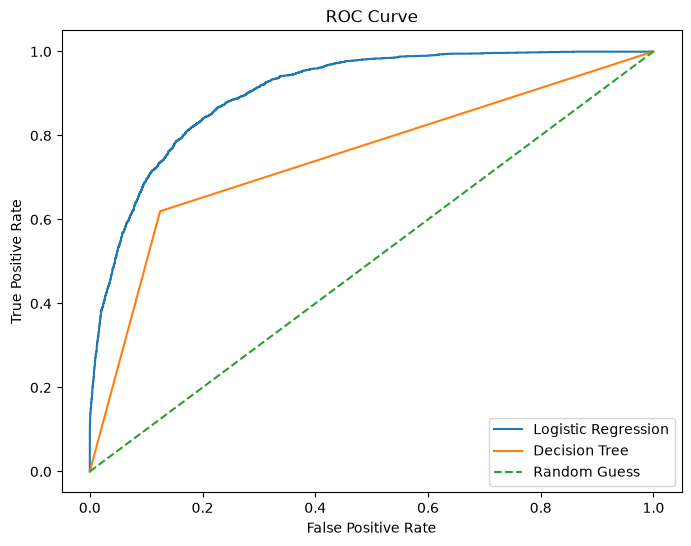

In [26]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curve for Logistic Regression
logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_probabilities)

# Calculate ROC curve for Decision Tree
tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_probabilities)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label='Logistic Regression'
)

plt.plot(
    tree_fpr,
    tree_tpr,
    label='Decision Tree'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

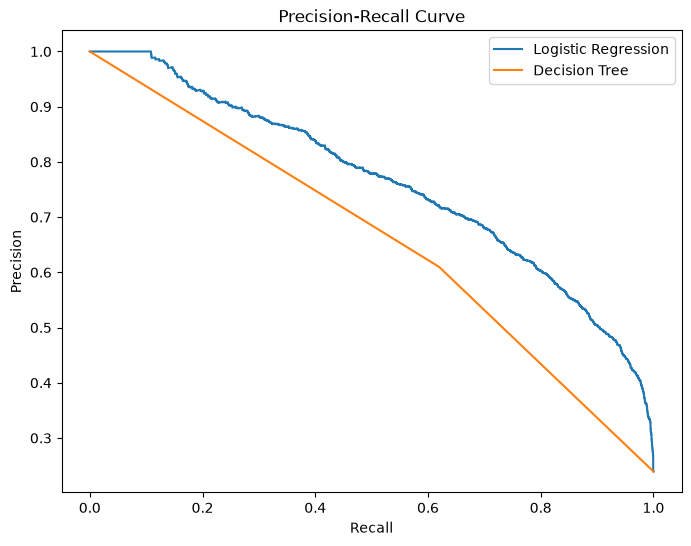

In [27]:
from sklearn.metrics import precision_recall_curve

# Calculate Precision-Recall curve for Logistic Regression
logistic_precision_curve, logistic_recall_curve, _ = precision_recall_curve(
    y_test,
    logistic_probabilities
)

# Calculate Precision-Recall curve for Decision Tree
tree_precision_curve, tree_recall_curve, _ = precision_recall_curve(
    y_test,
    tree_probabilities
)

# Plot Precision-Recall curves
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_recall_curve,
    logistic_precision_curve,
    label='Logistic Regression'
)

plt.plot(
    tree_recall_curve,
    tree_precision_curve,
    label='Decision Tree'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [28]:
from sklearn.metrics import confusion_matrix

# Confusion matrix for Logistic Regression
cm_logistic = confusion_matrix(y_test, logistic_predictions)

print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

# Confusion matrix for Decision Tree
cm_tree = confusion_matrix(y_test, tree_predictions)

print("\nDecision Tree Confusion Matrix:")
print(cm_tree)

Logistic Regression Confusion Matrix:
[[6951  480]
 [ 962 1376]]

Decision Tree Confusion Matrix:
[[6504  927]
 [ 889 1449]]


 Confusion Matrix Interpretation

Logistic Regression has more false negatives (962) than false positives (480). This means the model misses some people whose income is actually above $50K. Therefore, recall is an important metric to consider when evaluating this model.

Decision Tree has slightly more false positives (927) than false negatives (889). Overall, Logistic Regression performs better based on accuracy, precision, F1 score, ROC AUC, and PR AUC, although the Decision Tree has slightly higher recall. Therefore, Logistic Regression is currently the stronger candidate for further development.

In [29]:
#  Task 4 Get the preprocessing part of Logistic Regression
preprocessing = logistic_model.named_steps['preprocessing']

# Get feature names after preprocessing
feature_names = preprocessing.get_feature_names_out()

print("Total features:", len(feature_names))
print(feature_names)

Total features: 105
['numeric__age' 'numeric__fnlwgt' 'numeric__education-num'
 'numeric__capital-gain' 'numeric__capital-loss' 'numeric__hours-per-week'
 'categorical__workclass_Federal-gov' 'categorical__workclass_Local-gov'
 'categorical__workclass_Never-worked' 'categorical__workclass_Private'
 'categorical__workclass_Self-emp-inc'
 'categorical__workclass_Self-emp-not-inc'
 'categorical__workclass_State-gov' 'categorical__workclass_Without-pay'
 'categorical__education_10th' 'categorical__education_11th'
 'categorical__education_12th' 'categorical__education_1st-4th'
 'categorical__education_5th-6th' 'categorical__education_7th-8th'
 'categorical__education_9th' 'categorical__education_Assoc-acdm'
 'categorical__education_Assoc-voc' 'categorical__education_Bachelors'
 'categorical__education_Doctorate' 'categorical__education_HS-grad'
 'categorical__education_Masters' 'categorical__education_Preschool'
 'categorical__education_Prof-school'
 'categorical__education_Some-college'
 '

In [30]:
# Get coefficients from Logistic Regression
coefficients = logistic_model.named_steps['model'].coef_[0]

print("Number of coefficients:", len(coefficients))

Number of coefficients: 105


In [31]:
# Create a table of feature names and coefficients
coefficient_table = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Top 10 positive coefficients
top_positive = coefficient_table.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

print("Top 10 Positive Coefficients:")
print(top_positive)

Top 10 Positive Coefficients:
                                           Feature  Coefficient
3                            numeric__capital-gain     2.266560
32  categorical__marital-status_Married-civ-spouse     1.662327
31   categorical__marital-status_Married-AF-spouse     1.284302
73              categorical__native-country_France     0.904712
72             categorical__native-country_England     0.901708
40         categorical__occupation_Exec-managerial     0.803640
2                           numeric__education-num     0.735635
84             categorical__native-country_Ireland     0.734024
56                  categorical__relationship_Wife     0.721432
64            categorical__native-country_Cambodia     0.709139


In [32]:
# Top 10 negative coefficients
top_negative = coefficient_table.sort_values(
    by='Coefficient',
    ascending=True
).head(10)

print("Top 10 Negative Coefficients:")
print(top_negative)

Top 10 Negative Coefficients:
                                           Feature  Coefficient
67            categorical__native-country_Columbia    -1.432784
45         categorical__occupation_Priv-house-serv    -1.332626
34       categorical__marital-status_Never-married    -1.242189
98               categorical__native-country_South    -1.126642
69  categorical__native-country_Dominican-Republic    -0.987674
41         categorical__occupation_Farming-fishing    -0.933690
62                         categorical__sex_Female    -0.916386
53        categorical__relationship_Other-relative    -0.907951
44           categorical__occupation_Other-service    -0.861709
54             categorical__relationship_Own-child    -0.819657


In [33]:
# Get the Decision Tree model
tree = tree_model.named_steps['model']

# Get the depth of the tree
tree_depth = tree.get_depth()

print("Decision Tree depth:", tree_depth)

Decision Tree depth: 66


In [34]:
# Calculate training and test scores

train_score = tree_model.score(X_train, y_train)
test_score = tree_model.score(X_test, y_test)

print("Training Score:", round(train_score, 4))
print("Test Score:", round(test_score, 4))

Training Score: 0.9999
Test Score: 0.8141


In [36]:
# Get the Decision Tree model
tree = tree_model.named_steps['model']

print("Decision Tree model ready!")

Decision Tree model ready!


In [37]:
# Get the top 3 important features

tree_features = preprocessing.get_feature_names_out()

tree_importance = tree.feature_importances_

top_3 = pd.DataFrame({
    'Feature': tree_features,
    'Importance': tree_importance
}).sort_values(by='Importance', ascending=False).head(3)

print("Top 3 important features:")
print(top_3)

Top 3 important features:
                                           Feature  Importance
32  categorical__marital-status_Married-civ-spouse    0.201805
1                                  numeric__fnlwgt    0.193414
2                           numeric__education-num    0.108702


 Decision Tree Interpretation

The most important features in the Decision Tree are marital status, fnlwgt, and education-num. Education level is a sensible feature for predicting income because higher education can be related to higher income. Marital status can also be useful because income may be related to employment and household patterns. Overall, the important features seem reasonable, but the very high training score compared with the test score suggests that the tree may be overfitting.

Decision Tree Logic

The important features used by the Decision Tree seem reasonable for predicting income. Education level can be related to income, and marital status may also provide useful information. However, the very high training score (0.9999) compared with the test score (0.8141) suggests that the Decision Tree is overfitting.

Task 5: Model Selection and Future Plan

Based on the evaluation results, Logistic Regression is selected for further development. It achieved better overall performance than the Decision Tree, with an accuracy of 0.8524, precision of 0.7414, F1 score of 0.6562, ROC AUC of 0.9042, and PR AUC of 0.7632. The Decision Tree had a slightly higher recall of 0.6198 compared with 0.5885 for Logistic Regression, but Logistic Regression performed better on the other major metrics. Therefore, Logistic Regression is currently the stronger model for this classification task.

The Decision Tree also showed a very high training score of 0.9999 compared with a test score of 0.8141, which indicates possible overfitting. Logistic Regression is therefore a better candidate for further improvement because it provides stronger overall test performance and is easier to interpret using its coefficients.

Preprocessing Plan for Day 3

For the next stage, I plan to test different preprocessing choices to see if the model performance can be improved. I will consider different categorical missing-value handling methods and compare the results. I will also keep the preprocessing pipeline so that the same preprocessing steps can be reused consistently without causing data leakage.

Reusable Preprocessing Pipeline

The preprocessing pipeline is stored in the preprocessor variable and is already used inside both the Logistic Regression and Decision Tree pipelines. It can therefore be reused for future models and experiments.